In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anshtanwar/metro-interstate-traffic-volume/Metro_Interstate_Traffic_Volume.csv


In [2]:
import kagglehub

path = kagglehub.dataset_download("anshtanwar/metro-interstate-traffic-volume")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/anshtanwar/metro-interstate-traffic-volume


In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/anshtanwar/metro-interstate-traffic-volume/Metro_Interstate_Traffic_Volume.csv')

In [4]:
df.describe()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,3259.818355,281.205870,0.334264,0.000222,49.362231
std,1986.860670,13.338232,44.789133,0.008168,39.015750
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1193.000000,272.160000,0.000000,0.000000,1.000000
50%,3380.000000,282.450000,0.000000,0.000000,64.000000
75%,4933.000000,291.806000,0.000000,0.000000,90.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000


In [5]:
df.info

<bound method DataFrame.info of        traffic_volume holiday    temp  rain_1h  snow_1h  clouds_all  \
0                5545     NaN  288.28      0.0      0.0          40   
1                4516     NaN  289.36      0.0      0.0          75   
2                4767     NaN  289.58      0.0      0.0          90   
3                5026     NaN  290.13      0.0      0.0          90   
4                4918     NaN  291.14      0.0      0.0          75   
...               ...     ...     ...      ...      ...         ...   
48199            3543     NaN  283.45      0.0      0.0          75   
48200            2781     NaN  282.76      0.0      0.0          90   
48201            2159     NaN  282.73      0.0      0.0          90   
48202            1450     NaN  282.09      0.0      0.0          90   
48203             954     NaN  282.12      0.0      0.0          90   

       weather_main     weather_description         date_time  
0            Clouds        scattered clouds  02-10-

In [6]:
list(df.columns)

['traffic_volume',
 'holiday',
 'temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_main',
 'weather_description',
 'date_time']

In [7]:
df = df[df['rain_1h'] != 9831.3]
df = df.drop('snow_1h', axis=1)

In [8]:
df = df[(df['temp'] > 200) & (df['temp'] < 320)]

In [9]:
num_cols = df.select_dtypes(include='number')
num_cols_names = df.select_dtypes(include='number').columns
print(num_cols)

       traffic_volume    temp  rain_1h  clouds_all
0                5545  288.28      0.0          40
1                4516  289.36      0.0          75
2                4767  289.58      0.0          90
3                5026  290.13      0.0          90
4                4918  291.14      0.0          75
...               ...     ...      ...         ...
48199            3543  283.45      0.0          75
48200            2781  282.76      0.0          90
48201            2159  282.73      0.0          90
48202            1450  282.09      0.0          90
48203             954  282.12      0.0          90

[48193 rows x 4 columns]


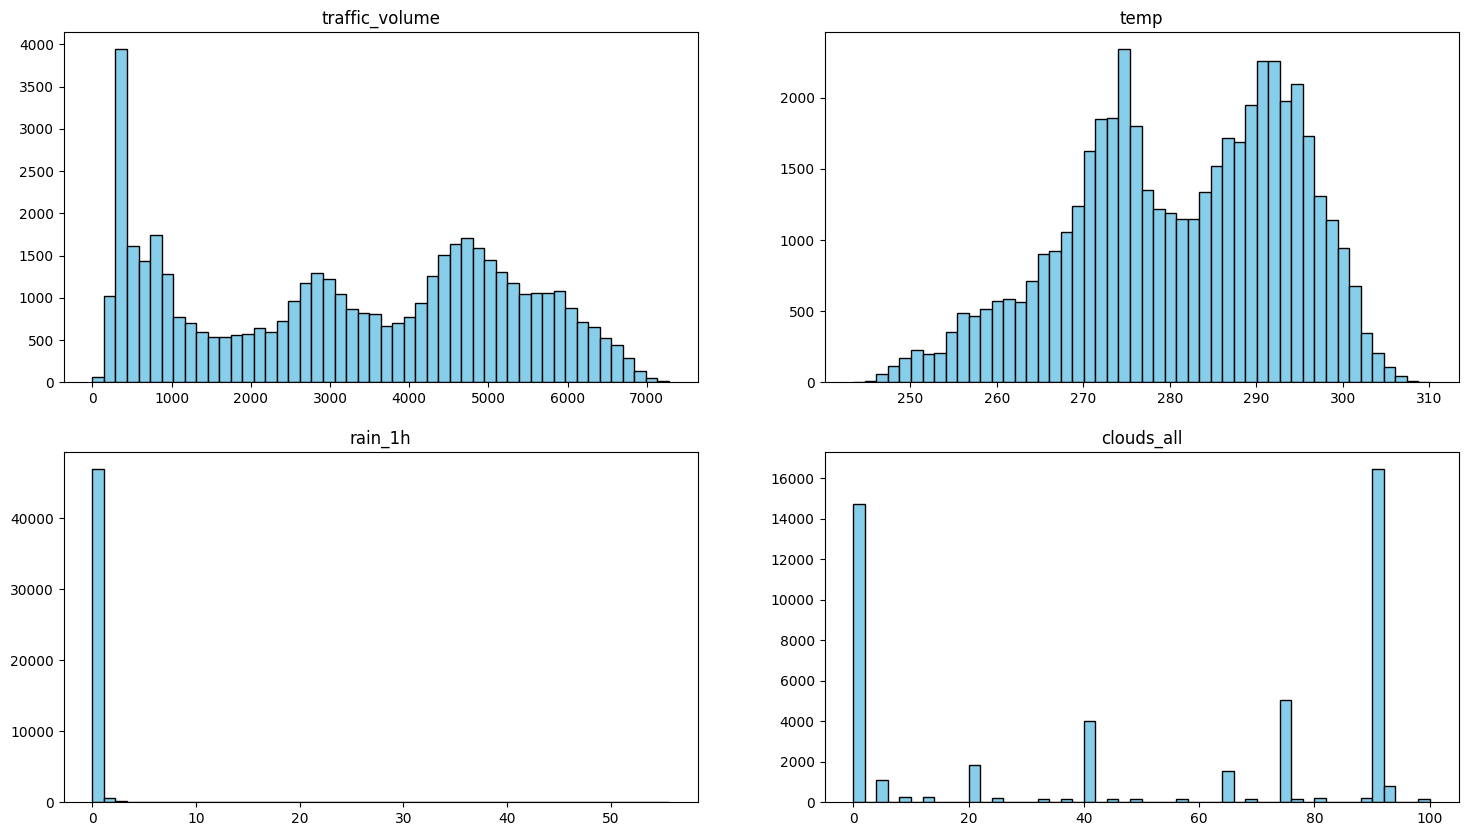

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i in range(len(num_cols_names)):
    axes[i // 2, i % 2].hist(df[num_cols_names[i]], bins=50, edgecolor='black', color='skyblue')
    axes[i // 2, i % 2].set_title(num_cols_names[i])

In [11]:
num_cols.describe()

,traffic_volume,temp,rain_1h,clouds_all
count,48193.000000,48193.000000,48193.000000,48193.000000
mean,3260.174029,281.263786,0.130342,49.371942
std,1986.754010,12.709364,1.003480,39.013548
min,0.000000,243.390000,0.000000,0.000000
25%,1194.000000,272.180000,0.000000,1.000000
50%,3380.000000,282.460000,0.000000,64.000000
75%,4933.000000,291.810000,0.000000,90.000000
max,7280.000000,310.070000,55.630000,100.000000


In [12]:
from scipy import stats

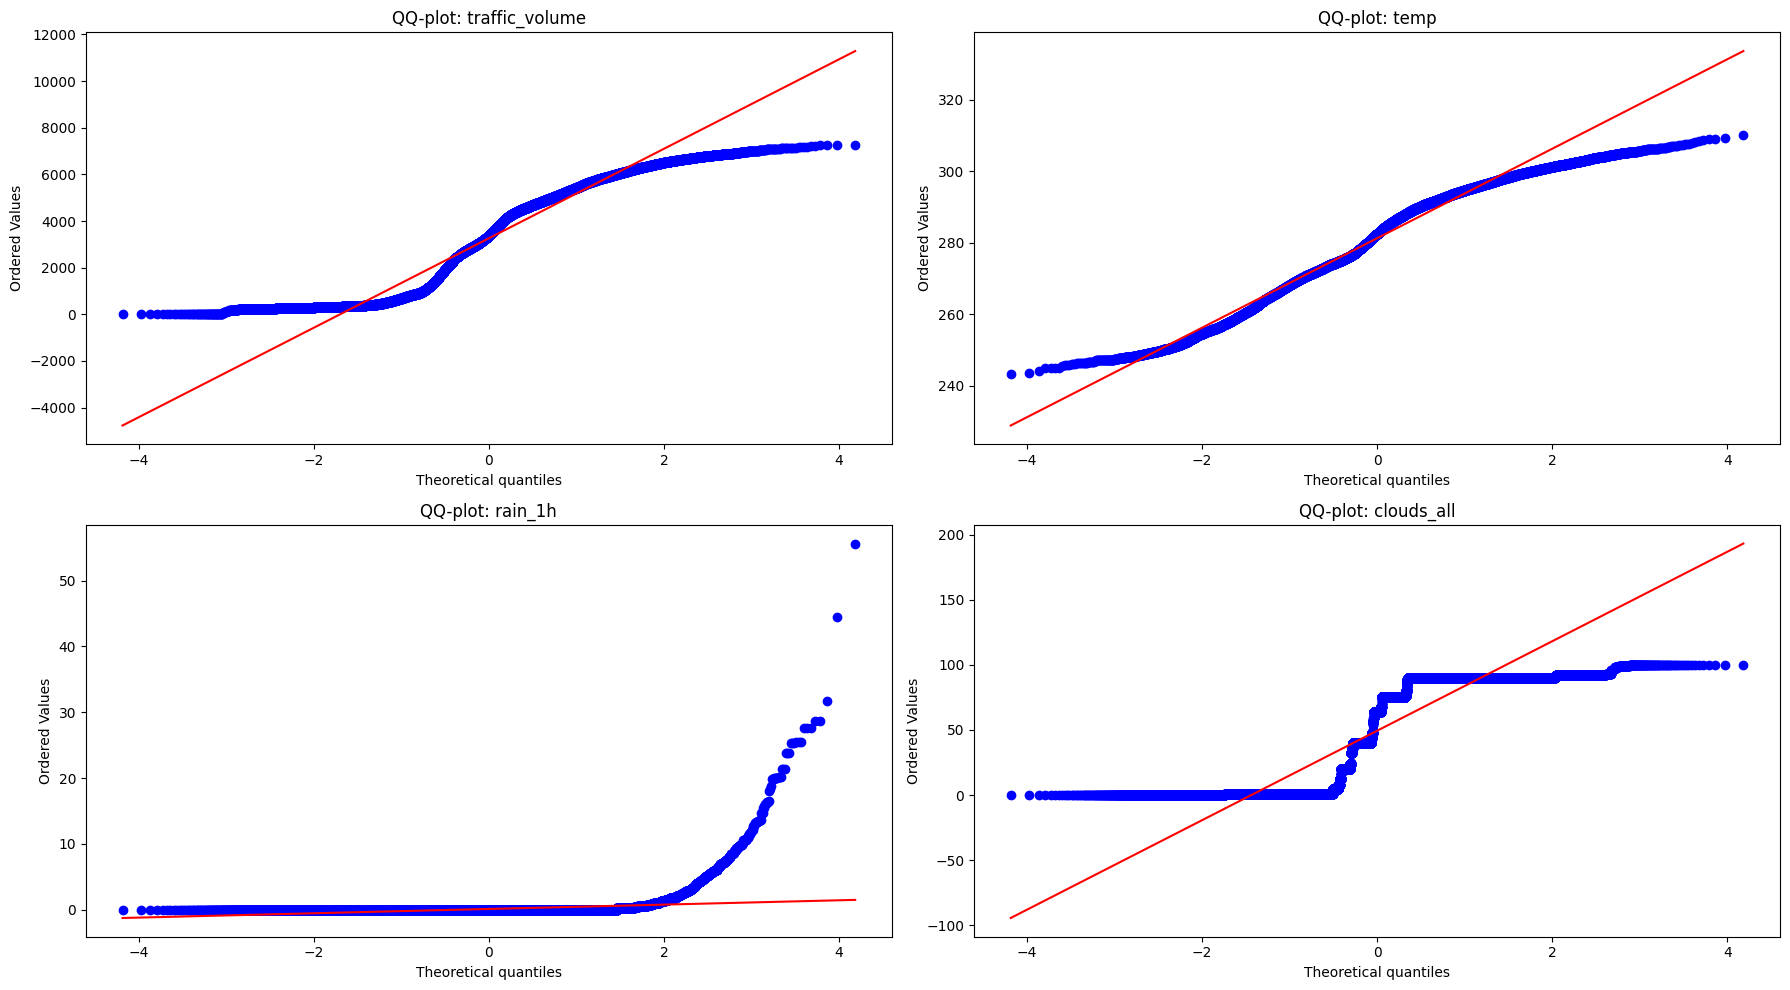

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i in range(len(num_cols_names)):
    stats.probplot(df[num_cols_names[i]], dist="norm", plot=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(f'QQ-plot: {num_cols_names[i]}')

plt.tight_layout()
plt.show()

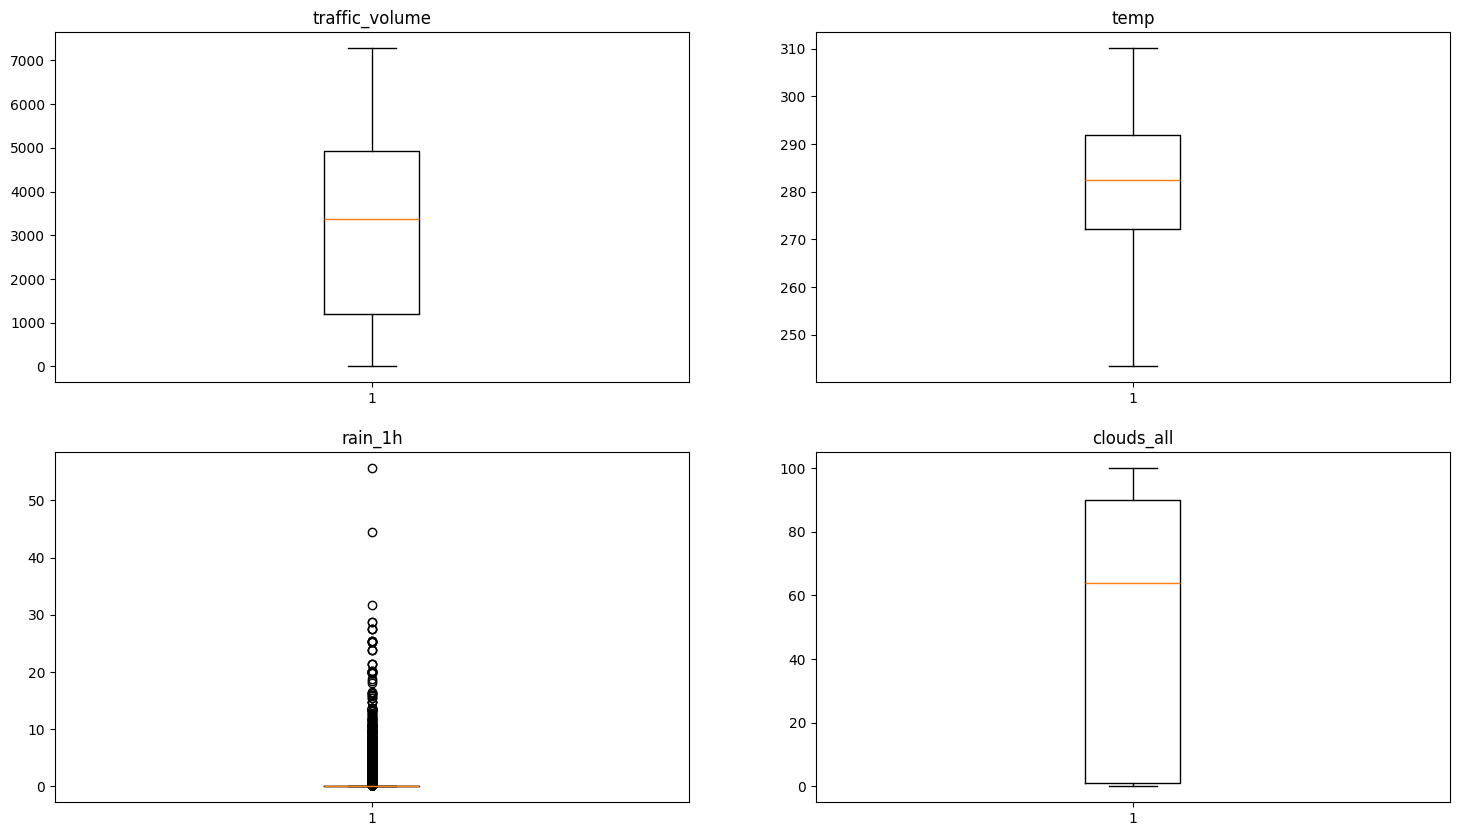

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i in range(len(num_cols_names)):
    axes[i // 2, i % 2].boxplot(df[num_cols_names[i]])
    axes[i // 2, i % 2].set_title(num_cols_names[i])

In [15]:
Q1, Q3 = df['traffic_volume'].quantile(0.25), df['traffic_volume'].quantile(0.75)
IQR = Q3 - Q1
mask = (df['traffic_volume'] >= Q1 - 3 * IQR) & (df['traffic_volume'] <= Q3 + 3 * IQR)

df = df[mask]

Удалены невозможные значения и использован 3IQR для таргета

In [16]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True)
df = df.set_index('date_time').sort_index()

In [17]:
y = df['traffic_volume'].values
x = y - y.mean()
c0 = (x ** 2).mean()
max_lag = 400

acf_f = np.array([(x[:len(x) - lag] * x[lag:]).mean() / c0 for lag in range(max_lag + 1)])

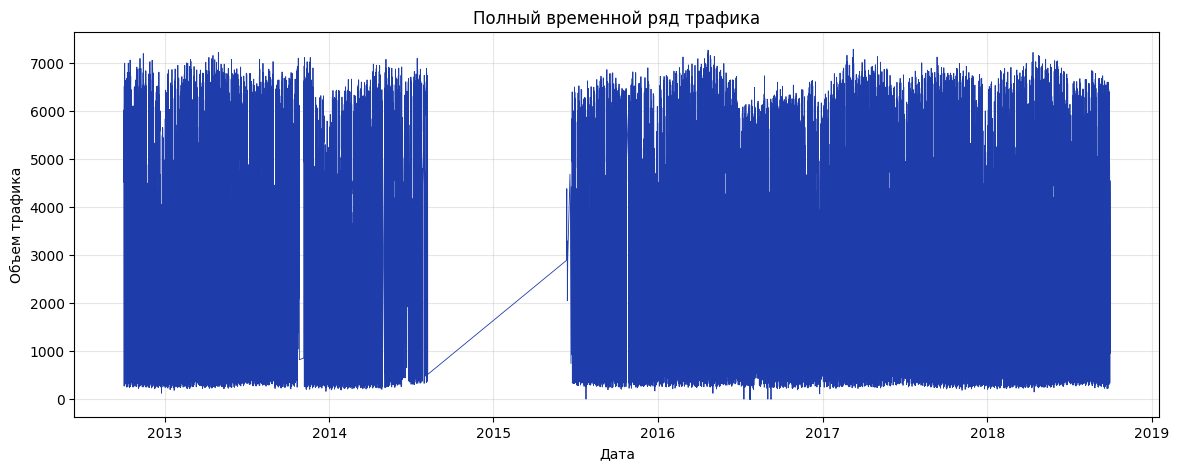

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['traffic_volume'], color='#1E3CAA', lw=0.6)
plt.title('Полный временной ряд трафика')
plt.xlabel('Дата')
plt.ylabel('Объем трафика')
plt.grid(alpha=0.3)
plt.show()

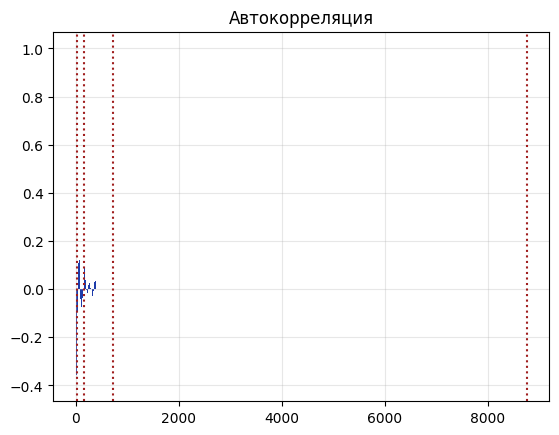

In [19]:
plt.bar(range(max_lag + 1), acf_f, color='#1E3CAA', width=1.0)
plt.axvline(24, color='#A01E1E', ls=':', label='суточная сезонность')
plt.axvline(168, color='#A01E1E', ls=':', label='недельная сезонность')
plt.axvline(720, color='#A01E1E', ls=':', label='месячная сезонность')
plt.axvline(8760, color='#A01E1E', ls=':', label='годовая сезонность')
plt.title('Автокорреляция')
plt.grid(alpha=0.3)
plt.show()

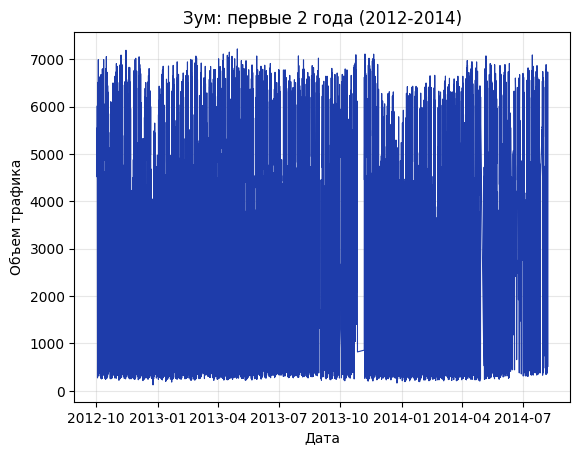

In [20]:
mask_2years = df.index < '2014-10-02'
df_zoom = df[mask_2years]

plt.plot(df_zoom.index, df_zoom['traffic_volume'], 
         color='#1E3CAA', lw=0.8)
plt.title('Зум: первые 2 года (2012-2014)')
plt.xlabel('Дата')
plt.ylabel('Объем трафика')
plt.grid(alpha=0.3)
plt.show()

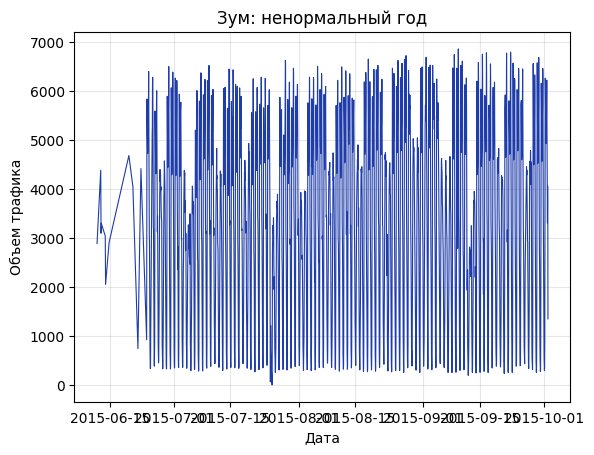

In [21]:
mask_abnorm_year = (df.index < '2015-10-02') & (df.index > '2014-10-02')
df_zoom = df[mask_abnorm_year]

plt.plot(df_zoom.index, df_zoom['traffic_volume'], 
         color='#1E3CAA', lw=0.8)
plt.title('Зум: ненормальный год')
plt.xlabel('Дата')
plt.ylabel('Объем трафика')
plt.grid(alpha=0.3)
plt.show()

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

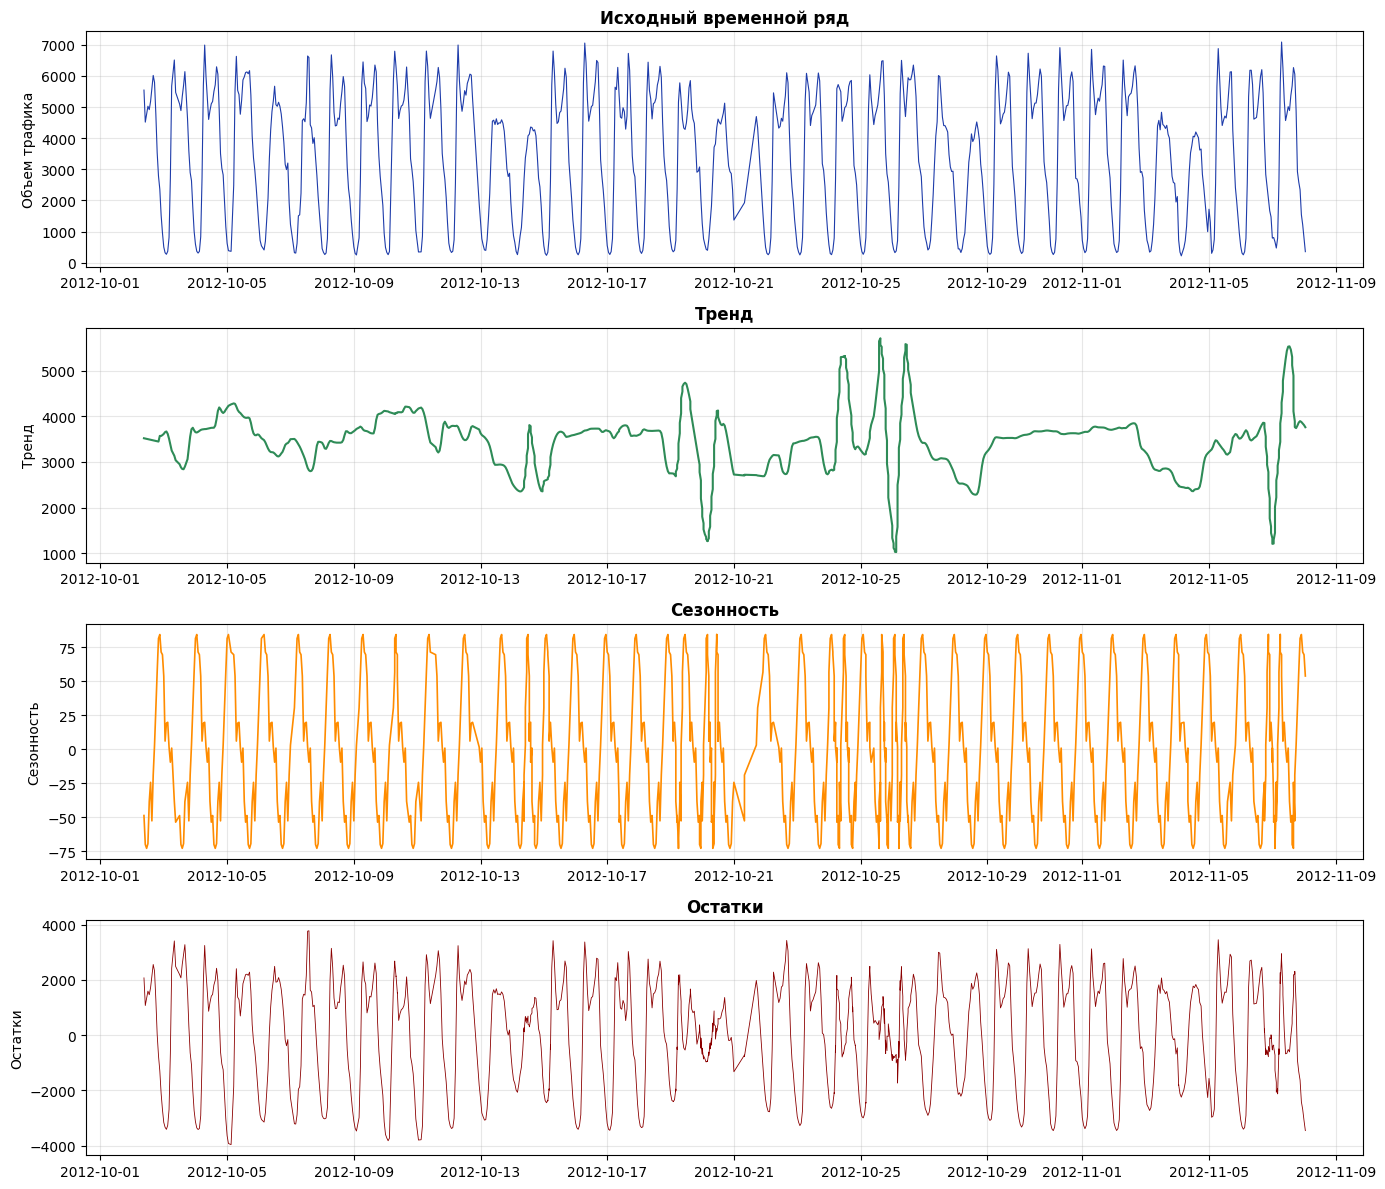

In [23]:
decomposition = seasonal_decompose(
    df['traffic_volume'], 
    model='additive',
    period=24,
    extrapolate_trend='freq'
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(df.index[:1000], decomposition.observed[:1000], color='#1E3CAA', lw=0.8)
axes[0].set_title('Исходный временной ряд', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Объем трафика')
axes[0].grid(alpha=0.3)

axes[1].plot(df.index[:1000], decomposition.trend[:1000], color='#2E8B57', lw=1.5)
axes[1].set_title('Тренд', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Тренд')
axes[1].grid(alpha=0.3)

axes[2].plot(df.index[:1000], decomposition.seasonal[:1000], color='#FF8C00', lw=1.2)
axes[2].set_title('Сезонность', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Сезонность')
axes[2].grid(alpha=0.3)

axes[3].plot(df.index[:1000], decomposition.resid[:1000], color='#8B0000', lw=0.6)
axes[3].set_title('Остатки', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Остатки')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
from statsmodels.graphics.tsaplots import plot_pacf

<Figure size 1400x500 with 0 Axes>

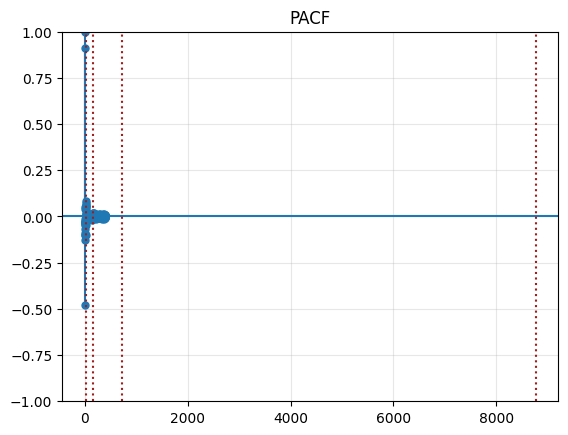

In [25]:
plt.figure(figsize=(14, 5))
plot_pacf(df['traffic_volume'], lags=400, method='ywm')
plt.axvline(24, color='#A01E1E', ls=':', label='суточная сезонность')
plt.axvline(168, color='#A01E1E', ls=':', label='недельная сезонность')
plt.axvline(720, color='#A01E1E', ls=':', label='месячная сезонность')
plt.axvline(8760, color='#A01E1E', ls=':', label='годовая сезонность')
plt.title('PACF')
plt.grid(alpha=0.3)
plt.show()

In [26]:
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox

In [27]:
adf_result = adfuller(df['traffic_volume'])
print(adf_result[0], adf_result[1])

-28.015874171139302 0.0


In [28]:
shapiro_result = shapiro(df['traffic_volume'].sample(n=min(5000, len(df['traffic_volume'])), random_state=42))
print(shapiro_result[0], shapiro_result[1])

0.9324002483710715 7.53035787359323e-43


In [29]:
ljung_box_result = acorr_ljungbox(df['traffic_volume'], lags=[24], return_df=True)
print(ljung_box_result)

          lb_stat  lb_pvalue
24  155342.012636        0.0


1. Ряд нестационарен
2. Есть суточная сезонность
3. После декомпозиции в остатках осталась структура => можно выудить ещё сезонность

In [30]:
print(df['holiday'].unique())
print(df['weather_main'].unique())
print(df['weather_description'].unique())

[nan 'Columbus Day' 'Veterans Day' 'Thanksgiving Day' 'Christmas Day'
 'New Years Day' 'Washingtons Birthday' 'Memorial Day' 'Independence Day'
 'State Fair' 'Labor Day' 'Martin Luther King Jr Day']
['Clouds' 'Clear' 'Rain' 'Drizzle' 'Mist' 'Haze' 'Fog' 'Thunderstorm'
 'Snow' 'Squall' 'Smoke']
['scattered clouds' 'broken clouds' 'overcast clouds' 'sky is clear'
 'few clouds' 'light rain' 'light intensity drizzle' 'mist' 'haze' 'fog'
 'proximity shower rain' 'drizzle' 'moderate rain' 'heavy intensity rain'
 'proximity thunderstorm' 'thunderstorm with light rain'
 'proximity thunderstorm with rain' 'heavy snow' 'heavy intensity drizzle'
 'snow' 'thunderstorm with heavy rain' 'freezing rain' 'shower snow'
 'light rain and snow' 'light intensity shower rain' 'SQUALLS'
 'thunderstorm with rain' 'proximity thunderstorm with drizzle'
 'thunderstorm' 'Sky is Clear' 'very heavy rain'
 'thunderstorm with light drizzle' 'light snow'
 'thunderstorm with drizzle' 'smoke' 'shower drizzle' 'light sho

In [31]:
df['is_holiday'] = df['holiday'].notna().astype(int)
df = df.drop('holiday', axis=1)

In [32]:
df = df.drop('weather_description', axis=1)

In [33]:
df = pd.concat([df, pd.get_dummies(df['weather_main'], prefix='weather')], axis=1)
df = df.drop('weather_main', axis=1)

In [34]:
for lag in range(1, 25):
    df[f'lag_{lag}'] = df['traffic_volume'].shift(lag)

for lag in [24, 48, 168]:
    df[f'seasonal_lag_{lag}'] = df['traffic_volume'].shift(lag)

df['diff_1'] = df['traffic_volume'].diff(1)
df['diff_24'] = df['traffic_volume'].diff(24)

for lag in range(1, 11):
    df[f'log_lag_{lag}'] = np.log1p(df['traffic_volume'].shift(lag))

In [35]:
temp = {}
windows = [3, 6, 12, 24, 72, 168]

for window in windows:
    rolling = df['traffic_volume'].rolling(window=window)
    temp[f'rolling_mean_{window}'] = rolling.mean()
    temp[f'rolling_median_{window}'] = rolling.median()
    temp[f'rolling_std_{window}'] = rolling.std()
    temp[f'rolling_min_{window}'] = rolling.min()
    temp[f'rolling_max_{window}'] = rolling.max()
    temp[f'rolling_range_{window}'] = temp[f'rolling_max_{window}'] - temp[f'rolling_min_{window}']
    temp[f'rolling_var_{window}'] = rolling.var()
    temp[f'rolling_q25_{window}'] = rolling.quantile(0.25)
    temp[f'rolling_q75_{window}'] = rolling.quantile(0.75)
    temp[f'rolling_iqr_{window}'] = temp[f'rolling_q75_{window}'] - temp[f'rolling_q25_{window}']

In [36]:
df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [37]:
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
temp = {}
base = df['traffic_volume']

for alpha in alphas:
    temp[f'ema_{alpha}'] = base.ewm(alpha=alpha).mean()  
    temp[f'dema_{alpha}'] = temp[f'ema_{alpha}'].ewm(alpha=alpha).mean()
    temp[f'tema_{alpha}'] = temp[f'dema_{alpha}'].ewm(alpha=alpha).mean()
df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [38]:
from scipy import stats
from scipy.signal import periodogram

In [39]:
temp = {}

for period in [14, 21, 30]:
    delta = df['traffic_volume'].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(com=period-1, adjust=False).mean()
    avg_loss = loss.ewm(com=period-1, adjust=False).mean()
    rs = avg_gain / avg_loss
    temp[f'rsi_{period}'] = 100 - (100 / (1 + rs))

for period in [14, 21]:
    low_min = df['traffic_volume'].rolling(window=period).min()
    high_max = df['traffic_volume'].rolling(window=period).max()
    temp[f'stoch_k_{period}'] = 100 * (df['traffic_volume'] - low_min) / (high_max - low_min)
    temp[f'stoch_d_{period}'] = temp[f'stoch_k_{period}'].rolling(window=3).mean()

for period in [14, 21]:
    high_max = df['traffic_volume'].rolling(window=period).max()
    low_min = df['traffic_volume'].rolling(window=period).min()
    temp[f'williams_r_{period}'] = -100 * (high_max - df['traffic_volume']) / (high_max - low_min)

for period in [1, 12, 24, 168]:
    temp[f'roc_{period}'] = df['traffic_volume'].pct_change(periods=period) * 100

for period in [1, 12, 24]:
    temp[f'momentum_{period}'] = df['traffic_volume'] - df['traffic_volume'].shift(period)

ema_12 = df['traffic_volume'].ewm(span=12).mean()
ema_26 = df['traffic_volume'].ewm(span=26).mean()
temp['macd'] = ema_12 - ema_26
temp['macd_signal'] = temp['macd'].ewm(span=9).mean()
temp['macd_histogram'] = temp['macd'] - temp['macd_signal']

for period in [20, 50]:
    rolling_mean = df['traffic_volume'].rolling(window=period).mean()
    rolling_std = df['traffic_volume'].rolling(window=period).std()
    temp[f'bb_upper_{period}'] = rolling_mean + (rolling_std * 2)
    temp[f'bb_middle_{period}'] = rolling_mean
    temp[f'bb_lower_{period}'] = rolling_mean - (rolling_std * 2)
    temp[f'bb_width_{period}'] = (temp[f'bb_upper_{period}'] - temp[f'bb_lower_{period}']) / rolling_mean
    temp[f'bb_position_{period}'] = (df['traffic_volume'] - temp[f'bb_lower_{period}']) / (temp[f'bb_upper_{period}'] - temp[f'bb_lower_{period}'])

for period in [14, 21]:
    temp[f'atr_{period}'] = df['traffic_volume'].diff().abs().rolling(window=period).mean()

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [40]:
temp = {}

temp['hour'] = df.index.hour
temp['dayofweek'] = df.index.dayofweek
temp['dayofmonth'] = df.index.day
temp['month'] = df.index.month
temp['quarter'] = df.index.quarter
temp['dayofyear'] = df.index.dayofyear
temp['weekofyear'] = df.index.isocalendar().week

temp['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
temp['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
temp['dayofweek_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
temp['dayofweek_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
temp['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
temp['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
temp['dayofyear_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
temp['dayofyear_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

temp['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
temp['is_month_start'] = df.index.is_month_start.astype(int)
temp['is_month_end'] = df.index.is_month_end.astype(int)

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [41]:
from statsmodels.tsa.stattools import acf, pacf

temp = {}
windows = [24, 72, 168]
for window in windows:
    rolling = base.rolling(window=window)
    temp[f'acf_lag1_w{window}'] = rolling.apply(
        lambda x: acf(x, nlags=1, fft=False)[1] if len(x) == window else np.nan,
        raw=False
    )
    
    temp[f'pacf_lag1_w{window}'] = rolling.apply(
        lambda x: pacf(x, nlags=1, method='ywm')[1] if len(x) == window else np.nan,
        raw=False
    )

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [42]:
!pip install antropy

In [43]:
import antropy as ant

temp = {}
windows = [24, 72, 168]
for window in windows:
    rolling = base.rolling(window=window)
    
    temp[f'apen_w{window}'] = rolling.apply(
        lambda x: ant.app_entropy(x, order=2, metric='chebyshev') if len(x) == window else np.nan,
        raw=False
    )
    
    temp[f'sampen_w{window}'] = rolling.apply(
        lambda x: ant.sample_entropy(x, order=2, metric='chebyshev') if len(x) == window else np.nan,
        raw=False
    )
    
    temp[f'permen_w{window}'] = rolling.apply(
        lambda x: ant.perm_entropy(x, normalize=True) if len(x) == window else np.nan,
        raw=False
    )

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [44]:
!pip install nolds -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 4.0 MB/s eta 0:00:00a 0:00:01


In [49]:
import nolds

temp = {}
windows = [168]

for window in windows:
    rolling = base.rolling(window=window)
    
    temp[f'hurst_w{window}'] = rolling.apply(
        lambda x: nolds.hurst_rs(x) if len(x) == window else np.nan,
        raw=False
    )
    
    temp[f'dfa_w{window}'] = rolling.apply(
        lambda x: nolds.dfa(x) if len(x) == window else np.nan,
        raw=False
    )

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [46]:
from scipy.stats import variation
from scipy.signal import find_peaks

In [47]:
from numpy.lib.stride_tricks import sliding_window_view
import warnings

warnings.filterwarnings('ignore', message=r'.*R\^2 score.*')
warnings.filterwarnings('ignore', category=RuntimeWarning)

temp = {}
window = 168
rolling = base.rolling(window=window)

temp[f'corr_dim_w{window}'] = rolling.apply(
    lambda x: float(nolds.corr_dim(np.asarray(x), emb_dim=5)) if len(x) == window else np.nan,
    raw=False
)

temp[f'lyapunov_w{window}'] = rolling.apply(
    lambda x: float(nolds.lyap_r(np.asarray(x), emb_dim=5, lag=1, min_tsep=10)) if len(x) == window else np.nan,
    raw=False
)

x_arr = base.values
windows_arr = sliding_window_view(x_arr, window)
n_windows = len(windows_arr)

rr_arr = np.full(n_windows, np.nan)
det_arr = np.full(n_windows, np.nan)
lam_arr = np.full(n_windows, np.nan)

threshold = 0.2
n = window

for i in range(n_windows):
    w = windows_arr[i]
    w_norm = (w - np.mean(w)) / (np.std(w) + 1e-10)
    
    dist = np.abs(w_norm[:, None] - w_norm[None, :])
    rec = (dist < threshold).astype(int)
    np.fill_diagonal(rec, 0)
    
    rec_sum = np.sum(rec)
    if rec_sum > 0:
        rr = rec_sum / (n * (n - 1))
        
        det_count = 0
        for k in range(1, n):
            diag = np.diag(rec, k)
            if len(diag) > 0:
                diffs = np.diff(np.concatenate(([0], diag, [0])))
                starts = np.where(diffs == 1)[0]
                ends = np.where(diffs == -1)[0]
                lengths = ends - starts
                det_count += np.sum(lengths[lengths >= 2])
        det = det_count / rec_sum
        
        lam_count = 0
        for col in range(n):
            col_data = rec[:, col]
            diffs = np.diff(np.concatenate(([0], col_data, [0])))
            starts = np.where(diffs == 1)[0]
            ends = np.where(diffs == -1)[0]
            lengths = ends - starts
            lam_count += np.sum(lengths[lengths >= 2])
        lam = lam_count / rec_sum
    else:
        rr, det, lam = np.nan, np.nan, np.nan
        
    rr_arr[i] = rr
    det_arr[i] = det
    lam_arr[i] = lam

pad = np.full(window - 1, np.nan)
temp[f'rr_w{window}'] = np.concatenate([pad, rr_arr])
temp[f'det_w{window}'] = np.concatenate([pad, det_arr])
temp[f'lam_w{window}'] = np.concatenate([pad, lam_arr])

temp[f'cv_w{window}'] = rolling.apply(
    lambda x: float(variation(np.asarray(x), ddof=1)) if len(x) == window else np.nan,
    raw=False
)

temp[f'hhi_w{window}'] = rolling.apply(
    lambda x: float(np.sum((np.asarray(x) / np.sum(np.asarray(x))) ** 2)) if len(x) == window and np.sum(np.asarray(x)) != 0 else np.nan,
    raw=False
)

temp[f'zero_cross_w{window}'] = rolling.apply(
    lambda x: float(np.sum(np.diff(np.sign(np.asarray(x) - np.mean(np.asarray(x)))) != 0)) if len(x) == window else np.nan,
    raw=False
)

temp[f'extrema_w{window}'] = rolling.apply(
    lambda x: float(len(find_peaks(np.asarray(x))[0]) + len(find_peaks(-np.asarray(x))[0])) if len(x) == window else np.nan,
    raw=False
)

temp[f'energy_w{window}'] = rolling.apply(
    lambda x: float(np.sum(np.asarray(x) ** 2)) if len(x) == window else np.nan,
    raw=False
)

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [51]:
from scipy.fft import rfft, rfftfreq, dct
import pywt
from numpy.lib.stride_tricks import sliding_window_view

warnings.filterwarnings('ignore')

temp = {}
windows = [24, 168]

for window in windows:
    x_arr = base.values
    windows_arr = sliding_window_view(x_arr, window)
    n_windows = len(windows_arr)
    
    fft_harm1 = np.full(n_windows, np.nan)
    dom_freq = np.full(n_windows, np.nan)
    spec_centroid = np.full(n_windows, np.nan)
    spec_var = np.full(n_windows, np.nan)
    spec_skew = np.full(n_windows, np.nan)
    spec_kurt = np.full(n_windows, np.nan)
    spec_entropy = np.full(n_windows, np.nan)
    spec_energy = np.full(n_windows, np.nan)
    
    wav_total_energy = np.full(n_windows, np.nan)
    wav_entropy = np.full(n_windows, np.nan)
    wav_energy_ratio = np.full(n_windows, np.nan)
    wav_levels = np.full(n_windows, np.nan)
    
    dct_low_freq_ratio = np.full(n_windows, np.nan)
    dct_l1_norm = np.full(n_windows, np.nan)
    dct_std = np.full(n_windows, np.nan)
    
    for i in range(n_windows):
        x = windows_arr[i]
        
        fft_vals = rfft(x)
        psd = (np.abs(fft_vals) ** 2) / len(x)
        freqs = rfftfreq(len(x), d=1)
        
        psd_ac = psd[1:]
        freqs_ac = freqs[1:]
        
        if len(psd_ac) > 0 and np.sum(psd_ac) > 0:
            fft_harm1[i] = np.abs(fft_vals[1])
            dom_freq[i] = freqs_ac[np.argmax(psd_ac)]
            spec_centroid[i] = np.sum(freqs_ac * psd_ac) / np.sum(psd_ac)
            spec_var[i] = np.sum((freqs_ac - spec_centroid[i]) ** 2 * psd_ac) / np.sum(psd_ac)
            
            std_f = np.sqrt(spec_var[i])
            if std_f > 1e-10:
                psd_norm = psd_ac / np.sum(psd_ac)
                spec_skew[i] = np.sum(((freqs_ac - spec_centroid[i]) / std_f) ** 3 * psd_norm)
                spec_kurt[i] = np.sum(((freqs_ac - spec_centroid[i]) / std_f) ** 4 * psd_norm) - 3
            
            spec_entropy[i] = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
            
        spec_energy[i] = np.sum(psd)
        
        level = min(4, pywt.dwt_max_level(len(x), 'db4'))
        if level > 0:
            coeffs = pywt.wavedec(x, 'db4', level=level)
            energies = np.array([np.sum(c ** 2) for c in coeffs])
            total_e = np.sum(energies)
            wav_total_energy[i] = total_e
            
            if total_e > 0:
                energies_norm = energies / (total_e + 1e-10)
                wav_entropy[i] = -np.sum(energies_norm * np.log(energies_norm + 1e-10))
                if len(energies) > 1:
                    wav_energy_ratio[i] = np.sum(energies[1:]) / (energies[0] + 1e-10)
            wav_levels[i] = float(level)
            
        dct_coeffs = dct(x, type=2, norm='ortho')
        total_dct_e = np.sum(dct_coeffs**2)
        n_low = max(1, len(dct_coeffs) // 4)
        low_freq_e = np.sum(dct_coeffs[:n_low]**2)
        
        dct_low_freq_ratio[i] = low_freq_e / (total_dct_e + 1e-10)
        dct_l1_norm[i] = np.sum(np.abs(dct_coeffs))
        dct_std[i] = np.std(dct_coeffs)

    pad = np.full(window - 1, np.nan)
    
    temp[f'fft_harm1_w{window}'] = np.concatenate([pad, fft_harm1])
    temp[f'dom_freq_w{window}'] = np.concatenate([pad, dom_freq])
    temp[f'spec_centroid_w{window}'] = np.concatenate([pad, spec_centroid])
    temp[f'spec_var_w{window}'] = np.concatenate([pad, spec_var])
    temp[f'spec_skew_w{window}'] = np.concatenate([pad, spec_skew])
    temp[f'spec_kurt_w{window}'] = np.concatenate([pad, spec_kurt])
    temp[f'spec_entropy_w{window}'] = np.concatenate([pad, spec_entropy])
    temp[f'spec_energy_w{window}'] = np.concatenate([pad, spec_energy])
    
    temp[f'wav_total_energy_w{window}'] = np.concatenate([pad, wav_total_energy])
    temp[f'wav_entropy_w{window}'] = np.concatenate([pad, wav_entropy])
    temp[f'wav_energy_ratio_w{window}'] = np.concatenate([pad, wav_energy_ratio])
    temp[f'wav_levels_w{window}'] = np.concatenate([pad, wav_levels])
    
    temp[f'dct_low_freq_ratio_w{window}'] = np.concatenate([pad, dct_low_freq_ratio])
    temp[f'dct_l1_norm_w{window}'] = np.concatenate([pad, dct_l1_norm])
    temp[f'dct_std_w{window}'] = np.concatenate([pad, dct_std])

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [53]:
temp = {}
windows = [24, 168]
base = df['traffic_volume']

for window in windows:
    rolling = base.rolling(window=window)
    ma_short = base.rolling(window=max(1, window // 3)).mean()
    ma_long = rolling.mean()
    
    temp[f'ma_ratio_{window}'] = ma_short / ma_long
    temp[f'distance_to_ma_{window}'] = base - ma_long
    temp[f'z_score_{window}'] = (base - ma_long) / rolling.std()
    
    bb_upper = ma_long + 2 * rolling.std()
    bb_lower = ma_long - 2 * rolling.std()
    temp[f'bb_position_{window}'] = (base - bb_lower) / (bb_upper - bb_lower)
    temp[f'bb_width_{window}'] = (bb_upper - bb_lower) / ma_long
    
    temp[f'volatility_change_{window}'] = rolling.std().pct_change()
    temp[f'trend_strength_{window}'] = (ma_short - ma_long) / rolling.std()
    
    if window == 168:
        ma_very_long = base.rolling(window=336).mean()
        temp['ma_ratio_168_336'] = ma_long / ma_very_long
        temp['distance_to_ma_336'] = base - ma_very_long

ema_12 = base.ewm(span=12, adjust=False).mean()
ema_26 = base.ewm(span=26, adjust=False).mean()
macd_line = ema_12 - ema_26
macd_signal = macd_line.ewm(span=9, adjust=False).mean()

temp['macd_cross_signal'] = (macd_line > macd_signal).astype(int)
temp['price_above_bb_middle'] = (base > base.rolling(20).mean()).astype(int)

diff_base = base.diff()
temp['is_peak'] = ((diff_base > 0) & (diff_base.shift(-1) < 0)).astype(int)
temp['is_valley'] = ((diff_base < 0) & (diff_base.shift(-1) > 0)).astype(int)

rolling_std_5 = base.rolling(5).std()
temp['strong_uptrend'] = (diff_base > rolling_std_5).astype(int)
temp['strong_downtrend'] = (diff_base < -rolling_std_5).astype(int)

df = pd.concat([df, pd.DataFrame(temp, index=df.index)], axis=1)

In [61]:
df.to_pickle('dataset_with_all_features.pkl')

In [62]:
df.to_csv('dataset_with_all_features.csv')

In [56]:
df.describe()

,traffic_volume,temp,rain_1h,clouds_all,is_holiday,lag_1,lag_2,lag_3,lag_4,lag_5,...,volatility_change_168,trend_strength_168,ma_ratio_168_336,distance_to_ma_336,macd_cross_signal,price_above_bb_middle,is_peak,is_valley,strong_uptrend,strong_downtrend
count,48193.000000,48193.000000,48193.000000,48193.000000,48193.000000,48192.000000,48191.000000,48190.000000,48189.000000,48188.000000,...,48025.000000,48026.000000,47858.000000,47858.000000,48193.000000,48193.000000,48193.000000,48193.000000,48193.000000,48193.000000
mean,3260.174029,281.263786,0.130342,49.371942,0.001266,3260.221883,3260.259447,3260.282299,3260.292245,3260.286378,...,0.000006,0.000286,0.999896,-0.189536,0.518146,0.524641,0.089349,0.088395,0.175959,0.124167
std,1986.754010,12.709364,1.003480,39.013548,0.035555,1986.746849,1986.750349,1986.764629,1986.784044,1986.804242,...,0.003651,0.229368,0.056897,1980.429984,0.499676,0.499398,0.285250,0.283871,0.380789,0.329776
min,0.000000,243.390000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.042317,-0.952643,0.582711,-3403.967262,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1194.000000,272.180000,0.000000,1.000000,0.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,...,-0.002193,-0.153396,0.968637,-2026.284970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3380.000000,282.460000,0.000000,64.000000,0.000000,3380.500000,3381.000000,3381.000000,3381.000000,3381.000000,...,0.000013,0.011762,1.000021,103.321429,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,4933.000000,291.810000,0.000000,90.000000,0.000000,4933.000000,4933.000000,4933.000000,4933.000000,4933.000000,...,0.002251,0.160907,1.033314,1664.739583,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,7280.000000,310.070000,55.630000,100.000000,1.000000,7280.000000,7280.000000,7280.000000,7280.000000,7280.000000,...,0.043753,0.959154,1.433447,4442.190476,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47854 entries, 0 to 47853
Columns: 262 entries, traffic_volume to strong_downtrend
dtypes: UInt32(1), bool(11), float64(232), int32(6), int64(12)
memory usage: 90.9 MB


In [59]:
df = df.dropna().reset_index(drop=True)